### House Prices EDA

Анализ датасета, преобразования и сохранение преобразованного датафрейма в файл для обучения

См. houseprices_main.ipynb - обучение

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ml_pipeline.regression.pipeline import RegressionPipeline
from ml_pipeline.regression.config import regression_config as config

In [3]:
df = pd.read_csv('data/house_prices/train.csv', index_col='Id')
test_df = pd.read_csv('data/house_prices/test.csv', index_col='Id')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [5]:
y = df['SalePrice']
df = df.drop(columns=['SalePrice'])

#### Категориальные и числовые фичи

In [6]:
df.dtypes.value_counts()

str        43
int64      33
float64     3
Name: count, dtype: int64

In [7]:
numerical_feats = df.dtypes[df.dtypes != "str"].index
categorical_feats = df.dtypes[df.dtypes == "str"].index

print(f"{len(numerical_feats)=}, {len(categorical_feats)=}")

len(numerical_feats)=36, len(categorical_feats)=43


In [8]:
numerical_feats

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')

In [9]:
categorical_feats

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

#### Посмотрим N/A значения

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

Или в процентах: 4 фичи имеют 80%+ пропущенных значений

<Axes: >

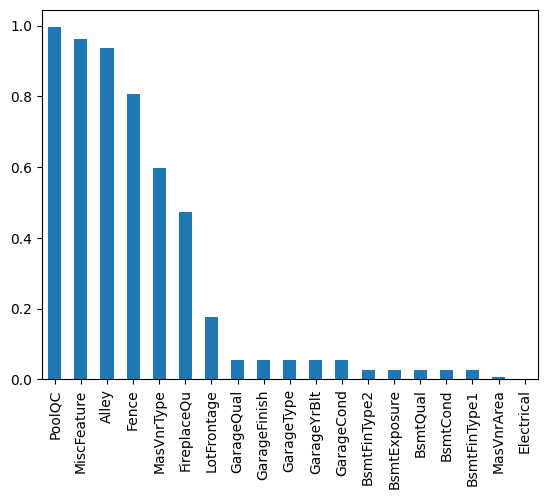

In [11]:
percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
percent[percent > 0].plot.bar()

Если почитать описание данных, можно увидеть, что для некоторых категориальных фич N/A означает отсутствие, что само по себе несет информацию

In [12]:
cols_fillna = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "GarageFinish",
    "GarageType",
    "Electrical",
    "KitchenQual",
    "SaleType",
    "Functional",
    "Exterior2nd",
    "Exterior1st",
    "BsmtExposure",
    "BsmtCond",
    "BsmtQual",
    "BsmtFinType1",
    "BsmtFinType2",
    "MSZoning",
    "Utilities",
]

not_specified_value = "Not_Specified"

for col in cols_fillna:
    df[col] = df[col].fillna(not_specified_value)
    test_df[col] = test_df[col].fillna(not_specified_value)

percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
percent

LotFrontage      0.177397
GarageYrBlt      0.055479
MasVnrArea       0.005479
LotArea          0.000000
Street           0.000000
                   ...   
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
Length: 79, dtype: float64

In [13]:
percent_test = (test_df.isnull().sum() / test_df.isnull().count()).sort_values(ascending=False)
percent_test = percent_test[percent_test > 0]
percent_test

LotFrontage     0.155586
GarageYrBlt     0.053461
MasVnrArea      0.010281
BsmtFullBath    0.001371
BsmtHalfBath    0.001371
BsmtFinSF2      0.000685
TotalBsmtSF     0.000685
BsmtUnfSF       0.000685
BsmtFinSF1      0.000685
GarageCars      0.000685
GarageArea      0.000685
dtype: float64

In [14]:
for p in percent_test.items():
    print(p[0] in numerical_feats)

True
True
True
True
True
True
True
True
True
True
True


Остальные фичи с N/A - числовые, их можно заменить средним, но уже после сплита на трейн и тест

См. BaseMeanImputer в base.preprocessing и конфиг base_mean_imputer в конфиге пайплайна регрессии

#### Таргет 

распределение не нормальное, нужно преобразовать, чтобы методы sklearn лучше работали

Для нормального нужно skew=0 и kurt=3

Преобразуем в log, но нужно будет перед сабмитом преобразовать обратно

y.skew()=np.float64(1.8828757597682129), y.kurt()=np.float64(6.536281860064529)


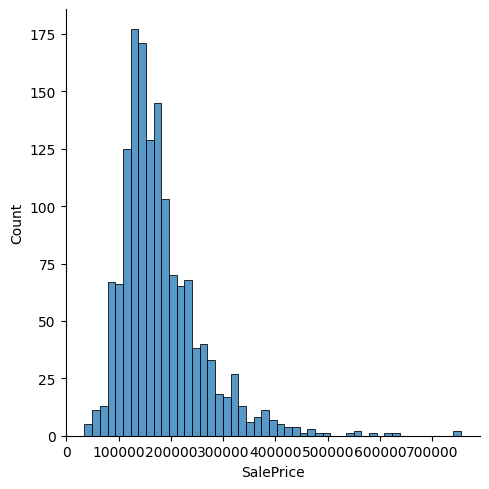

In [15]:
print(f"{y.skew()=}, {y.kurt()=}")

sns.displot(y)

y.skew()=np.float64(0.12133506220520406), y.kurt()=np.float64(0.8095319958036296)


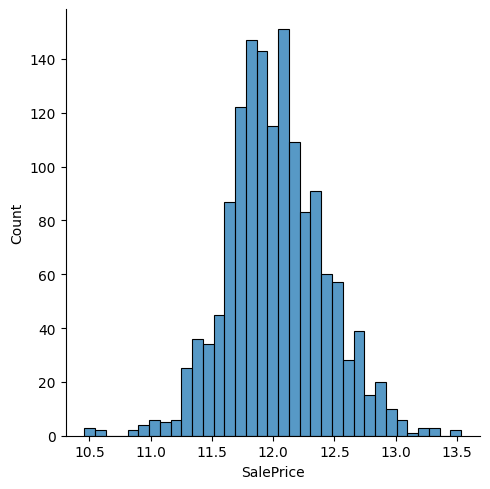

In [16]:
target_log = 'SalePrice_Log'

y = np.log(y)

sns.displot(y);

print(f"{y.skew()=}, {y.kurt()=}")

#### Распределение фич

Некоторые из них тоже стоит преобразовать в нормальные распределения

In [17]:
for col in numerical_feats:
    print(
        "{:15}".format(col),
        "skew: {:05.2f}".format(df[col].skew()),
        " ",
        "kurt: {:06.2f}".format(df[col].kurt()),
        end="",
    )

    logged = df[col]
    logged = np.log(logged)

    print(
        " | skew: {:.2f}".format(logged.skew()),
        " ",
        "kurt: {:.2f}".format(logged.kurt()),
    )

MSSubClass      skew: 01.41   kurt: 001.58 | skew: 0.23   kurt: -1.12
LotFrontage     skew: 02.16   kurt: 017.45 | skew: -0.76   kurt: 2.35
LotArea         skew: 12.21   kurt: 203.24 | skew: -0.14   kurt: 4.71
OverallQual     skew: 00.22   kurt: 000.10 | skew: -0.93   kurt: 4.29
OverallCond     skew: 00.69   kurt: 001.11 | skew: -0.64   kurt: 5.61
YearBuilt       skew: -0.61   kurt: -00.44 | skew: -0.64   kurt: -0.38
YearRemodAdd    skew: -0.50   kurt: -01.27 | skew: -0.51   kurt: -1.26
MasVnrArea      skew: 02.67   kurt: 010.08 | skew: nan   kurt: nan
BsmtFinSF1      skew: 01.69   kurt: 011.12 | skew: nan   kurt: nan
BsmtFinSF2      skew: 04.26   kurt: 020.11 | skew: nan   kurt: nan
BsmtUnfSF       skew: 00.92   kurt: 000.47 | skew: nan   kurt: nan
TotalBsmtSF     skew: 01.52   kurt: 013.25 | skew: nan   kurt: nan
1stFlrSF        skew: 01.38   kurt: 005.75 | skew: 0.08   kurt: 0.15
2ndFlrSF        skew: 00.81   kurt: -00.55 | skew: nan   kurt: nan
LowQualFinSF    skew: 09.01   kurt: 0

x:\DSML\Miniconda\envs\titanic\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\pandas\core\nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
x:\DSML\Miniconda\envs\titanic\Lib\site-packages\pandas\core\nanops.py:1364: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [18]:
feats_for_log = ["MSSubClass", "LotFrontage", "LotArea"]

Все преобразования не зависят от самого датасета, поэтому их можно сделать до сплита и сохранить в файл

In [19]:
df[config.data.target_col] = y

In [20]:
df.to_csv(f'data/house_prices/train_with_log_target.csv', index=True)

In [21]:
test_df.to_csv(f'data/house_prices/test_transformed.csv', index=True)